In [123]:
!pip install pillow

##3.  Exercise

##3.1 Task1

### Softmax Function

In [124]:
import numpy as np
def softmax(z):
  """
  Compute the softmax probabilities for a given input matrix.
  Parameters:
  z (numpy.ndarray): Logits (raw scores) of shape (m, n), where- m is the number of samples.- n is the number of classes.
  Returns:
  numpy.ndarray: Softmax probability matrix of shape (m, n), where
  each row sums to 1 and represents the probability
  distribution over classes.
  Notes:- The input to softmax is typically computed as: z = XW + b.- Uses numerical stabilization by subtracting the max value per row.
  """
  # Subtract max for numerical stability
  exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))

  return exp_z / np.sum(exp_z, axis=1, keepdims=True)

###Softmax Test Function

In [125]:
# This test case checks that each row in the resulting softmax probabilities sums to 1, which is the fundamental property of softmax.

# Example test case
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])

softmax_output = softmax(z_test)

# Verify if the sum of probabilities for each row is 1 using assert
row_sums = np.sum(softmax_output, axis=1)

# Assert that the sum of each row is 1
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"

print("Softmax function passed the test case!")

Softmax function passed the test case!


###PredictionFunction

In [126]:
def predict_softmax(X,W,b):
  """
  Predicttheclasslabelsforasetofsamplesusingthetrainedsoftmaxmodel.
  Parameters:
  X (numpy.ndarray):Featurematrixofshape(n,d),wherenisthenumberofsamplesand disthe
  numberoffeatures.
  W (numpy.ndarray):Weightmatrixofshape(d,c),wherecisthenumberofclasses.
  b (numpy.ndarray):Biasvectorofshape(c,).
  Returns:
  numpy.ndarray:Predictedclasslabelsofshape(n,),whereeachvalueistheindexof the
  predictedclass.
  """
  predicted_classes = np.argmax(softmax(np.dot(X, W) + b), axis=1)
  return predicted_classes

###Prediction Test Case

In [127]:
import numpy as np
# The test function ensures that the predicted class labels have the same number of elements as the input samples, verifying that the model produces a valid output shape.

# Define test case
X_test = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])  # Feature matrix (3 samples, 2 features)
W_test = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])    # Weights (2 features, 3 classes)
b_test = np.array([0.1, 0.2, 0.3])                      # Bias (3 classes)

# Expected Output:
# The function should return an array with class labels (0, 1, or 2)
y_pred_test = predict_softmax(X_test, W_test, b_test)

# Validate output shape
assert y_pred_test.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test.shape}"

# Print the predicted labels
print("Predicted class labels:", y_pred_test)

Predicted class labels: [1 1 0]


##3.2 Task2

###1. Implementation of Loss Function:

####Categorical Cross Entropy Loss:

In [128]:
import numpy as np

def loss_softmax(y_pred, y):
    """
    Compute the cross-entropy loss for a single sample.

    Parameters:
    y_pred (numpy.ndarray): Predicted probabilities of shape (c,) for a single sample,
                            where c is the number of classes.
    y (numpy.ndarray): True labels (one-hot encoded) of shape (c,), where c is the number of classes.

    Returns:
    float: Cross-entropy loss for the given sample.
    """
    # To avoid log(0), add a small epsilon
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    # Cross-entropy loss
    loss = -np.sum(y * np.log(y_pred))
    return loss

####Test case for Loss Function:

In [129]:
import numpy as np
#ThistestcaseCompareslossforcorrectvs.incorrectpredictions.
# Expectslowlossforcorrectpredictions.
# Expectshighlossforincorrectpredictions.
#Definecorrectpredictions(lowlossscenario)
y_true_correct =np.array([[1,0,0],[0,1,0],[0,0,1]])#Trueone-hotlabels
y_pred_correct =np.array([[0.9,0.05,0.05],
[0.1,0.85,0.05],
[0.05,0.1,0.85]])#Highconfidenceinthecorrectclass
#Defineincorrectpredictions(highloss scenario)
y_pred_incorrect =np.array([[0.05,0.05,0.9],#Highlyconfidentinthewrongclass
[0.1,0.05,0.85],
[0.85,0.1,0.05]])
#Computelossforbothcases
loss_correct=loss_softmax(y_pred_correct,y_true_correct)
loss_incorrect =loss_softmax(y_pred_incorrect,y_true_correct)
#Validatethat incorrectpredictionsleadtoahigherloss
assert loss_correct<loss_incorrect,f"Testfailed:Expectedloss_correct<loss_incorrect,butgot\n{loss_correct:.4f}>={loss_incorrect:.4f}"
#Printresults
print(f"Cross-EntropyLoss(CorrectPredictions):{loss_correct:.4f}")
print(f"Cross-EntropyLoss(IncorrectPredictions):{loss_incorrect:.4f}")

Cross-EntropyLoss(CorrectPredictions):0.4304
Cross-EntropyLoss(IncorrectPredictions):8.9872


###2.Implementation of Cost Function:

####Cost Function:

In [130]:
import numpy as np

def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.
    """

    n = X.shape[0]

    total_loss = -np.sum(
        y * np.log(
            np.exp(np.dot(X, W) + b - np.max(np.dot(X, W) + b, axis=1, keepdims=True)) /
            np.sum(np.exp(np.dot(X, W) + b - np.max(np.dot(X, W) + b, axis=1, keepdims=True)), axis=1, keepdims=True)
            + 1e-15
        )
    )

    # Return average loss
    return total_loss / n

####Test case for Cost Function.

In [131]:
# The test case assures that the cost for the incorrect prediction should be higher than for the correct prediction, confirming that the cost function behaves as expected.

import numpy as np

# Example 1: Correct Prediction (Closer predictions)
X_correct = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct = np.array([[1, 0], [0, 1]])
W_correct = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct = np.array([0.1, 0.1])

# Example 2: Incorrect Prediction (Far off predictions)
X_incorrect = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect = np.array([[1, 0], [0, 1]])
W_incorrect = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect = np.array([0.5, 0.6])

# Compute cost for correct predictions
cost_correct = cost_softmax(X_correct, y_correct, W_correct, b_correct)

# Compute cost for incorrect predictions
cost_incorrect = cost_softmax(X_incorrect, y_incorrect, W_incorrect, b_incorrect)

# Check condition
assert cost_incorrect > cost_correct, (
    f"Test failed: Incorrect cost {cost_incorrect} is not greater than correct cost {cost_correct}"
)

# Print results
print("Cost for correct prediction:", cost_correct)
print("Cost for incorrect prediction:", cost_incorrect)
print("Test passed!")

Cost for correct prediction: 0.0006234364133339325
Cost for incorrect prediction: 0.2993086135944598
Test passed!


##3.3 Task3

###1.Implementation of Compute Gradients:

####Computing Gradients against W and b

In [132]:
def compute_gradient_softmax(x,y,w,b):
  """
  Compute the gradients of the cost function with respect to weights and biases.
  Parameters:
  X (numpy.ndarray): Feature matrix of shape (n,d).
  y (numpy.ndarray): True labels (one-hot encoded) of shape (n,c).
  W (numpy.ndarray): Weight matrix of shape (d,c).
  b (numpy.ndarray): Bias vector of shape (c,).
  Returns:
  tuple: Gradients with respect to weights (d,c) and biases (c,).
  """
  n = x.shape[0]
  # Calculate logits
  logits = np.dot(x, w) + b
  # Calculate softmax probabilities using the defined softmax function
  y_pred_probs = softmax(logits)

  # Calculate the difference (predicted probabilities - true labels)
  diff = y_pred_probs - y

  # Compute gradients with respect to weights
  grad_W = (1/n) * np.dot(x.T, diff)

  # Compute gradients with respect to biases
  grad_b = (1/n) * np.sum(diff, axis=0)

  return grad_W, grad_b

####Test case for compute gradient softmax Function

In [133]:
import numpy as np

# Define a simple feature matrix and true labels
x_test = np.array([[0.2,0.8],[0.5,0.5],[0.9,0.1]]) # Feature matrix (3 samples, 2 features)
y_test = np.array([[1,0,0],[0,1,0],[0,0,1]]) # True labels (one-hot encoded, 3 classes)

# Define weight matrix and bias vector
w_test = np.array([[0.4,0.2,0.1],[0.3,0.7,0.5]]) # Weights (2 features, 3 classes)
b_test = np.array([0.1,0.2,0.3]) # Bias (3 classes)

# Compute the gradients using the function
grad_w, grad_b = compute_gradient_softmax(x_test, y_test, w_test, b_test)

# Manually compute the predicted probabilities (using softmax function)
z_test = np.dot(x_test, w_test) + b_test # Corrected: x_test should be multiplied by w_test
y_pred_test = softmax(z_test)

# Compute the manually computed gradients
grad_w_manual = np.dot(x_test.T,(y_pred_test - y_test)) / x_test.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test,axis=0) / x_test.shape[0]

# Assert that the gradients computed by the function match the manually computed gradients
assert np.allclose(grad_w,grad_w_manual),f"Test failed: Gradients w.r.t. w are not equal.\nExpected:{grad_w_manual}\nGot:{grad_w}"
assert np.allclose(grad_b,grad_b_manual),f"Test failed: Gradients w.r.t. b are not equal.\nExpected:{grad_b_manual}\nGot:{grad_b}"

# Print the gradients for verification
print("Gradient w.r.t. w:",grad_w)
print("Gradient w.r.t. b:",grad_b)
print("Test passed!")

Gradient w.r.t. w: [[ 0.1031051   0.01805685 -0.12116196]
 [-0.13600547  0.00679023  0.12921524]]
Gradient w.r.t. b: [-0.03290036  0.02484708  0.00805328]
Test passed!


####Gradient Descent Algorithm

In [134]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimize the weights and biases.
    Parameters:
    X (numpy.ndarray): Feature matrix of shape (n, d).
    y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
    W (numpy.ndarray): Weight matrix of shape (d, c).
    b (numpy.ndarray): Bias vector of shape (c,).
    alpha (float): Learning rate.
    n_iter (int): Number of iterations.
    show_cost (bool): Whether to display the cost at intervals.
    Returns:
    tuple: Optimized weights, biases, and cost history.
    """
    cost_history = []
    for i in range(n_iter):
        # Compute gradients
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # Your Code Here
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        if show_cost and i % 10 == 0:
            cost = cost_softmax(X, y, W, b) # Corrected function name
            cost_history.append(cost)
            print(f"Iteration {i}: cost = {cost}")

    return W, b, cost_history

##3.5 Task4

###1. Load and Prepare mnist Dataset:

####Load and Prepare Mnist Dataset:

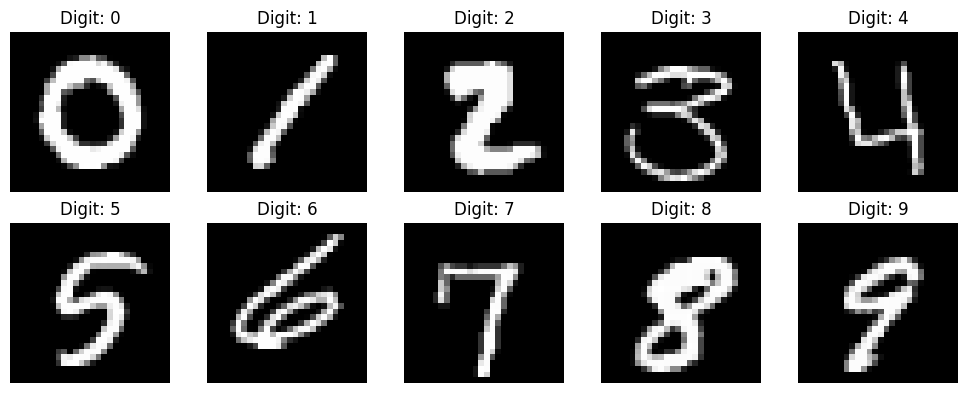

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
  """
  Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.
  Arguments:
  csv_file (str) : Path to the CSV file containing MNIST data.
  test_size (float) : Proportion of the data to use as the test set (default: 0.2).
  random_state (int) : Random seed for reproducibility (default: 42).
  Returns:
  x_train, x_test, y_train, y_test : Split dataset.
  """
  # Load dataset
  df = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/week2/mnist_train.csv")
  # Separate labels and features
  y = df.iloc[:, 0].values # First column is the label
  x=df.iloc[:,1:].values # Remaining columns are pixel values
  # Normalize pixel values (optional but recommended)
  x =x/255.0  # Scale values between 0 and 1
  # Split data into train and test sets
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=test_size,random_state=random_state)
  # Plotone sample image per class
  plot_sample_images(x,y)
  return x_train,x_test,y_train,y_test
  # Example usage

x_train, x_test, y_train, y_test = load_and_prepare_mnist("/content/drive/MyDrive/AI and Machine Learning/week2/mnist_train.csv")


###2. Plot Sample Image

In [136]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).
    Arguments:
    X (np.ndarray): Feature matrix containing pixel values.
    y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10,4))
    unique_classes = np.unique(y)  # Get unique class labels
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]  # Find first occurrence of the class
        image = X[index].reshape(28,28)
        plt.subplot(2,5,i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()


##3.5 Task5


###Training of the model

####Checking

In [137]:
# Assert that X and y have matching lengths
assert len(x_train) == len(y_train), f"Error: x and y have different lengths! x={len(x_train)}, y={len(y_train)}"

print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Move forward: Dimension of Feature Matrix X and label vector y matched.


####Training of the Softmax Regression Model

Iteration 0: cost = 2.2042811426849007
Iteration 10: cost = 1.4984520263706467
Iteration 20: cost = 1.1592085023388068
Iteration 30: cost = 0.9753704840876503
Iteration 40: cost = 0.8618512239725883
Iteration 50: cost = 0.7846971164978384
Iteration 60: cost = 0.7285825493898442
Iteration 70: cost = 0.6857195271594287
Iteration 80: cost = 0.6517564634792276
Iteration 90: cost = 0.6240740724272827
Iteration 100: cost = 0.6010002157212604
Iteration 110: cost = 0.5814157726516743
Iteration 120: cost = 0.5645423124152209
Iteration 130: cost = 0.5498208062117877
Iteration 140: cost = 0.536838861829836
Iteration 150: cost = 0.5252852212470202
Iteration 160: cost = 0.5149202818559588
Iteration 170: cost = 0.5055564074237469
Iteration 180: cost = 0.4970444244586865
Iteration 190: cost = 0.4892641430696336
Iteration 200: cost = 0.4821175648497674
Iteration 210: cost = 0.4755239263418554
Iteration 220: cost = 0.4694160223090968
Iteration 230: cost = 0.46373743781661725
Iteration 240: cost = 0.458

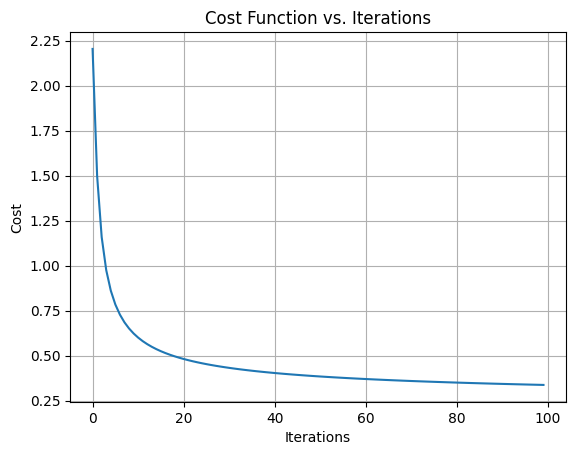

In [122]:
from sklearn.preprocessing import OneHotEncoder

# Check if y_train is one-hot encoded
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)  # Uses sparse_output=False for newer versions of sklearn
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))  # One-hot encode labels
    y_test = encoder.transform(y_test.reshape(-1, 1))        # One-hot encode test labels

# Now y_train is one-hot encoded, and we can proceed to use it
d = x_train.shape[1]  # Number of features (columns in x_train)
c = y_train.shape[1]  # Number of classes (columns in y_train after one-hot encoding)

# Initialize weights with small random values and biases with zeros
w = np.random.randn(d, c) * 0.01  # Small random weights initialized
b = np.zeros(c)                    # Bias initialized to 0

# Set hyperparameters for gradient descent
alpha = 0.1     # Learning rate
n_iter = 1000   # Number of iterations to run gradient descent

# Train the model using gradient descent
w_opt, b_opt, cost_history = gradient_descent_softmax(x_train, y_train, w, b, alpha, n_iter, show_cost=True)

# Plot the cost history to visualize the convergence
iterations = np.arange(len(cost_history))
plt.plot(iterations, cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()


##3.6 Task6

#### Evaluating Model Performance:

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Evaluation Function
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix, precision, recall, and F1-score.

    Parameters:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted labels

    Returns:
    tuple: Confusion matrix, precision, recall, F1 score
    """

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Compute precision, recall, and F1-score
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    return cm, precision, recall, f1

####Putting it all together:


confusion matrix:
[[778   0   1   1   3  12   9   0  11   1]
 [  1 889   2   1   1   1   2   2   9   1]
 [  6  10 736  12  25   2  12  17  25   1]
 [  2   5  26 800   1  41   6  10  28  18]
 [  1   1   7   2 774   4  11   2   2  35]
 [ 10   6   5  25  15 586  23   4  20   8]
 [  6   2   7   3   6   9 742   1   8   1]
 [  1  13  16   3  13   4   0 801   2  40]
 [  2  11   9  26   7  25   8   7 728  12]
 [  6   3   6  16  23   7   0  30   6 741]]
precision: 0.90
recall: 0.90
f1-score: 0.90


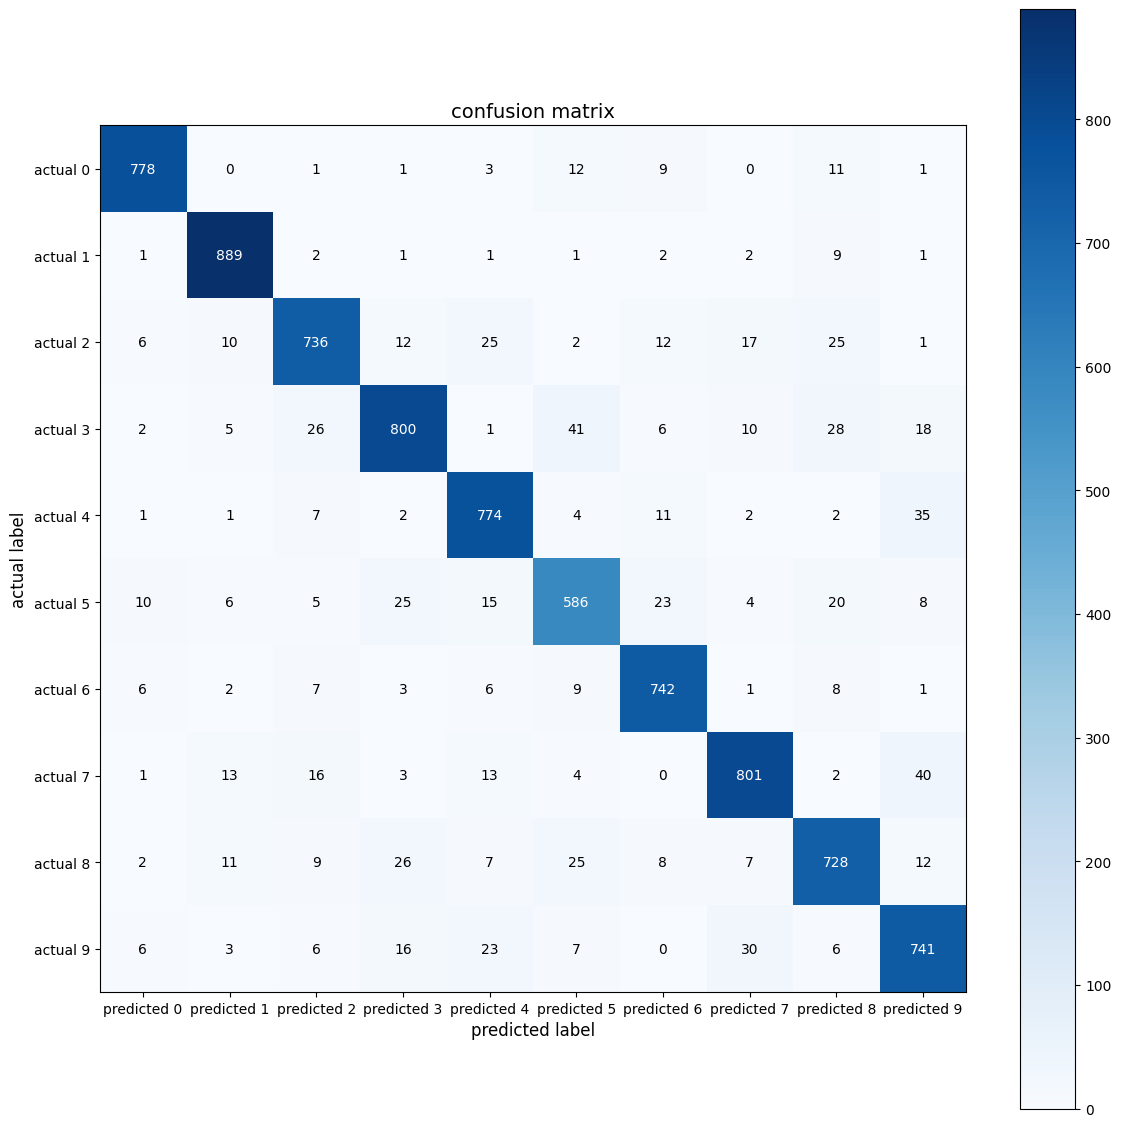

In [141]:
# prediction on the test set
y_pred_test = predict_softmax(x_test, w_opt, b_opt)

# evaluate accuracy
y_test_labels = y_test  # true labels in numeric form (y_test is already 1D labels)

# evaluate the model
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# print the evaluation metrics
print("\nconfusion matrix:")
print(cm)
print(f"precision: {precision:.2f}")
print(f"recall: {recall:.2f}")
print(f"f1-score: {f1:.2f}")

# visualizing the confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')  # use a colormap for better visualization

# dynamic number of classes
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'actual {i}' for i in range(num_classes)])

# add labels to each cell in the confusion matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha='center',
                va='center',
                color='white' if cm[i, j] > np.max(cm)/2 else 'black')

# add grid lines and axis labels
ax.grid(False)
plt.title('confusion matrix', fontsize=14)
plt.xlabel('predicted label', fontsize=12)
plt.ylabel('actual label', fontsize=12)

# adjust layout
plt.tight_layout()
plt.colorbar(cax)
plt.show()

## Exercise Linear Separability and Logistic Regression.

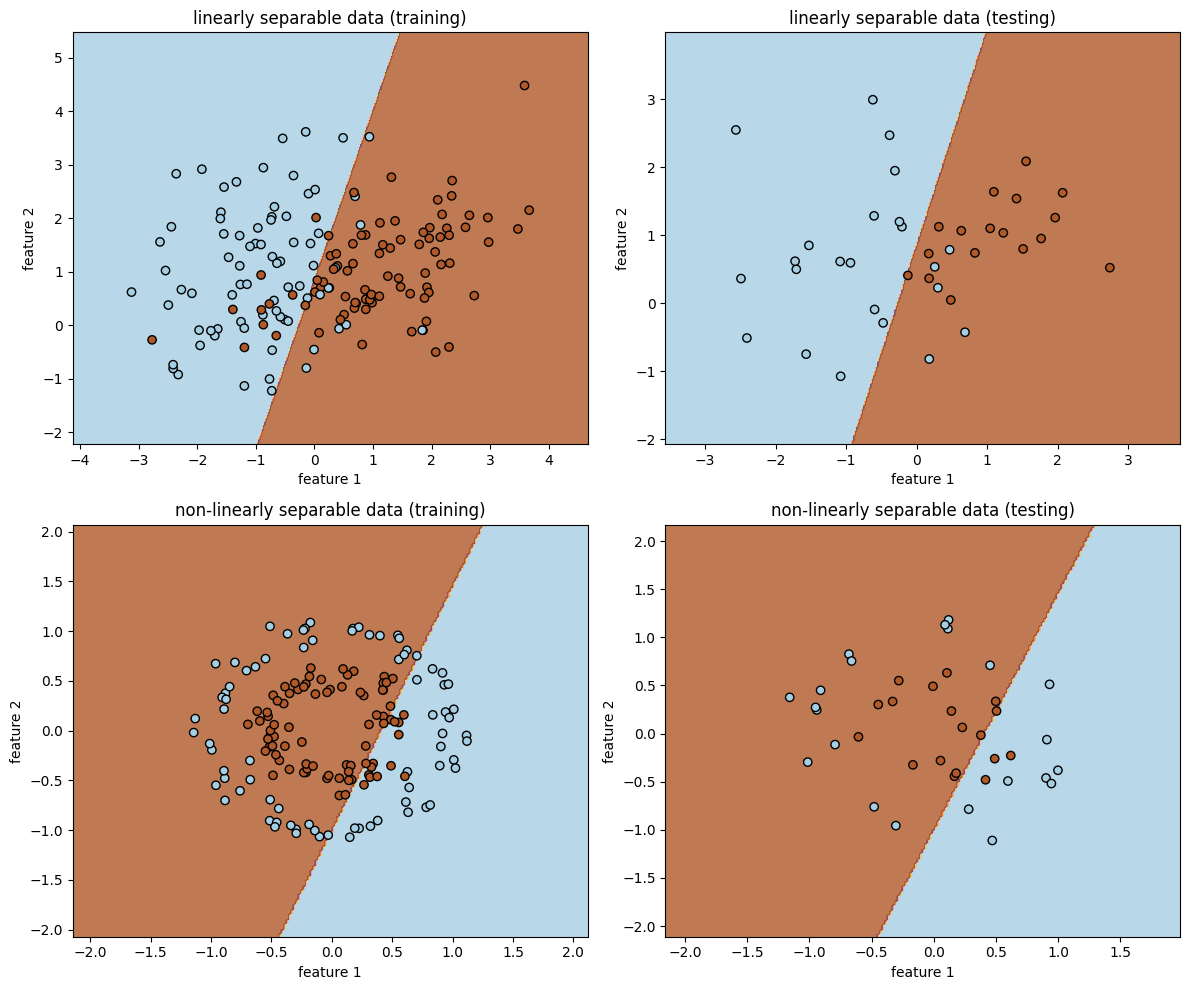

In [142]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# set random seed for reproducibility
np.random.seed(42)

# generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200,
    noise=0.1,
    factor=0.5,
    random_state=42
)

# split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# plot decision boundaries for linearly and non-linearly separable data
def plot_decision_boundary(ax, model, X, y, title):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)

    ax.set_title(title)
    ax.set_xlabel('feature 1')
    ax.set_ylabel('feature 2')

# create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# plot decision boundary for linearly separable data (training)
plot_decision_boundary(
    axes[0, 0],
    logistic_model_linear_separable,
    X_train_linear,
    y_train_linear,
    'linearly separable data (training)'
)

# plot decision boundary for linearly separable data (testing)
plot_decision_boundary(
    axes[0, 1],
    logistic_model_linear_separable,
    X_test_linear,
    y_test_linear,
    'linearly separable data (testing)'
)

# plot decision boundary for non-linearly separable data (training)
plot_decision_boundary(
    axes[1, 0],
    logistic_model_non_linear_separable,
    X_train_non_linear,
    y_train_non_linear,
    'non-linearly separable data (training)'
)

# plot decision boundary for non-linearly separable data (testing)
plot_decision_boundary(
    axes[1, 1],
    logistic_model_non_linear_separable,
    X_test_non_linear,
    y_test_non_linear,
    'non-linearly separable data (testing)'
)

plt.tight_layout()

# save the plots as png files
plt.savefig('decision_boundaries.png')

plt.show()

##Question- 2 Provide an interpretation of the output based on your understanding.

-> For linearly separable data, the model works well and separates classes clearly with a straight line.
->For non-linear data, it performs poorly because it cannot create curved boundaries.

##Question- 3 Describe any challenges you faced while implementing the code above.

-> while doing this code many challenges were occur and i fixing code errors also spacing, syntax, plotting the graph correctly, and understanding why the model fails on non-linear data.